# Con đường phục hồi lợi nhuận

Waterfall chart theo phong cách executive consulting, mô phỏng cách doanh nghiệp có thể thu hẹp khoảng hụt lợi nhuận thông qua nhiều đòn bẩy chiến lược phối hợp.

**Lưu ý:** Các giá trị trong biểu đồ là chỉ số minh họa để phục vụ storytelling và prescriptive analytics. Đây không phải số liệu kế toán hay forecast output từ model.

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

In [18]:
def configure_font():
    candidates = [
        Path("C:/Windows/Fonts/arial.ttf"),
        Path("C:/Windows/Fonts/segoeui.ttf"),
        Path("C:/Windows/Fonts/calibri.ttf"),
    ]
    for path in candidates:
        if path.exists():
            font_manager.fontManager.addfont(str(path))
            plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(path)).get_name()
            return
    plt.rcParams["font.family"] = "DejaVu Sans"


def resolve_output_dir():
    cwd = Path.cwd()
    if cwd.name == "report_visuals":
        return cwd
    candidate = cwd / "ai_eda" / "report_visuals"
    if candidate.exists():
        return candidate
    return cwd


configure_font()
OUT_DIR = resolve_output_dir()
OUT_DIR

WindowsPath('d:/Datathon-2026-Inlier/ai_eda/report_visuals')

In [19]:
labels = [
    'Khoảng hụt\nlợi nhuận hiện tại',
    'Tối ưu\nkhuyến mãi',
    'Giảm áp lực\ntồn kho',
    'Phục hồi\nchuyển đổi',
    'Cải thiện\ncơ cấu sản phẩm',
    'Giảm áp lực\ngiảm giá',
    'Lợi nhuận\ncó thể phục hồi',
]

# Chỉ số minh họa: khoảng hụt so với năm đỉnh = 0, trạng thái hiện tại = -100.
# Các bước dương thể hiện mức đóng góp giả định của từng strategic lever.
contributions = [-100, 24, 16, 22, 18, 14]
final_value = sum(contributions)
values = contributions + [final_value]

colors = [
    "#022812",  # start
    "#014116",  # lever 1
    "#027027",  # lever 2
    "#39B061",  # lever 3
    "#8FB79C",  # lever 4
    "#63D88A",  # lever 5
    "#6BE1AC",  # final
]

In [20]:

def create_profit_recovery_waterfall(labels, values, contributions, final_value, colors):
    fig, ax = plt.subplots(figsize=(15.2, 7.8), dpi=180)

    # ===== Background =====
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # ===== Minimal gridlines =====
    ax.grid(axis='y', color='#D9E2DC', linewidth=0.7, alpha=0.45)
    ax.set_axisbelow(True)

    x = np.arange(len(labels))
    width = 0.62

    cumulative = [0]
    for v in contributions:
        cumulative.append(cumulative[-1] + v)

    starts = [values[0]]
    current = values[0]

    for v in contributions:
        starts.append(current)
        current += v

    # ===== Initial bar =====
    ax.bar(
        x[0],
        values[0],
        width=width,
        color=colors[0],
        edgecolor='none'
    )

    # ===== Intermediate bars =====
    for i in range(1, len(labels) - 1):
        ax.bar(
            x[i],
            contributions[i-1],
            bottom=starts[i],
            width=width,
            color=colors[i],
            edgecolor='none'
        )

    # ===== Final bar emphasized =====
    ax.bar(
        x[-1],
        final_value,
        width=0.72,
        color=colors[-1],
        edgecolor='none'
    )

    # ===== Connector lines refined =====
    connector_color = '#AEBDB4'

    for i in range(len(labels) - 2):
        y = starts[i + 1]
        ax.plot(
            [x[i] + width/2, x[i+1] - width/2],
            [y, y],
            color=connector_color,
            linewidth=1.0,
            alpha=0.6
        )

    # ===== Value labels =====
    ax.text(
        x[0],
        values[0] / 2,
        f"{values[0]}",
        ha='center',
        va='center',
        fontsize=12,
        color='white',
        fontweight='bold'
    )

    running = values[0]

    for i, c in enumerate(contributions, start=1):
        running += c

        ax.text(
            x[i],
            running + 3,
            f"+{c}",
            ha='center',
            va='bottom',
            fontsize=11,
            color='#1E2E27',
            fontweight='bold'
        )

    ax.text(
        x[-1],
        final_value + 3,
        "~94% khoảng hụt\ncó thể phục hồi",
        ha='center',
        va='bottom',
        fontsize=11,
        color='#184D32',
        fontweight='bold'
    )

    # ===== Titles =====
    fig.text(
        0.055,
        0.93,
        "Con đường phục hồi lợi nhuận",
        fontsize=24,
        fontweight='bold',
        color='#1E2E27'
    )

    fig.text(
        0.055,
        0.885,
        "Lợi nhuận có thể cải thiện đáng kể khi phối hợp các hành động vận hành và thương mại.",
        fontsize=13,
        color='#617267'
    )

    # ===== Section headers =====
    ax.text(
        1.6,
        11,
        "ĐÒN BẨY THƯƠNG MẠI",
        fontsize=11,
        color='#617267',
        fontweight='bold',
        ha='center'
    )

    ax.plot(
        [0.8, 4.2],
        [8, 8],
        color='#D7E0DA',
        linewidth=1.1
    )

    ax.text(
        2.9,
        -121,
        "CẢI THIỆN VẬN HÀNH",
        fontsize=11,
        color='#617267',
        fontweight='bold',
        ha='center'
    )

    ax.plot(
        [1.6, 5.4],
        [-114, -114],
        color='#D7E0DA',
        linewidth=1.1
    )

    # ===== Minimal annotations =====
    ax.annotate(
        "Tối ưu khuyến mãi giúp\nhạn chế bào mòn biên lợi nhuận",
        xy=(1, -76),
        xytext=(0.55, -49),
        fontsize=10.5,
        color='#617267',
        arrowprops=dict(
            arrowstyle='-',
            color='#B8C5BE',
            lw=1.1
        )
    )

    ax.annotate(
        "Giảm tồn kho giúp giảm\náp lực markdown và xả hàng",
        xy=(2, -60),
        xytext=(2.55, -90),
        fontsize=10.5,
        color='#617267',
        arrowprops=dict(
            arrowstyle='-',
            color='#B8C5BE',
            lw=1.1
        )
    )

    ax.annotate(
        "Phục hồi chuyển đổi giúp\ncải thiện hiệu quả monetization",
        xy=(3, -38),
        xytext=(3.65, -27),
        fontsize=10.5,
        color='#617267',
        arrowprops=dict(
            arrowstyle='-',
            color='#B8C5BE',
            lw=1.1
        )
    )

    # ===== Clean axes =====
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11, color='#2F3B34')

    ax.set_ylabel(
        "Chỉ số tác động lợi nhuận\n(khoảng hụt so với đỉnh = 0)",
        fontsize=12,
        color='#425248'
    )

    ax.set_ylim(-130, 25)
    ax.set_yticks([-100, -75, -50, -25, 0])

    ax.tick_params(axis='y', labelsize=10.5, colors='#617267')
    ax.tick_params(axis='x', length=0, pad=14)

    # ===== Remove unnecessary spines =====
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    ax.spines['bottom'].set_color('#D7E0DA')

    # ===== Footnote =====
    fig.text(
        0.08,
        0.06,
        "Minh hoạ prescriptive analytics. Giá trị mang tính định hướng chiến lược, không phải forecast tài chính.",
        fontsize=9.5,
        color='#7B8B81'
    )

    plt.subplots_adjust(left=0.08, right=0.98, top=0.83, bottom=0.18)

    return fig, ax


d:\Datathon-2026-Inlier\ai_eda\report_visuals\profit_recovery_waterfall.png
d:\Datathon-2026-Inlier\ai_eda\report_visuals\profit_recovery_waterfall.svg


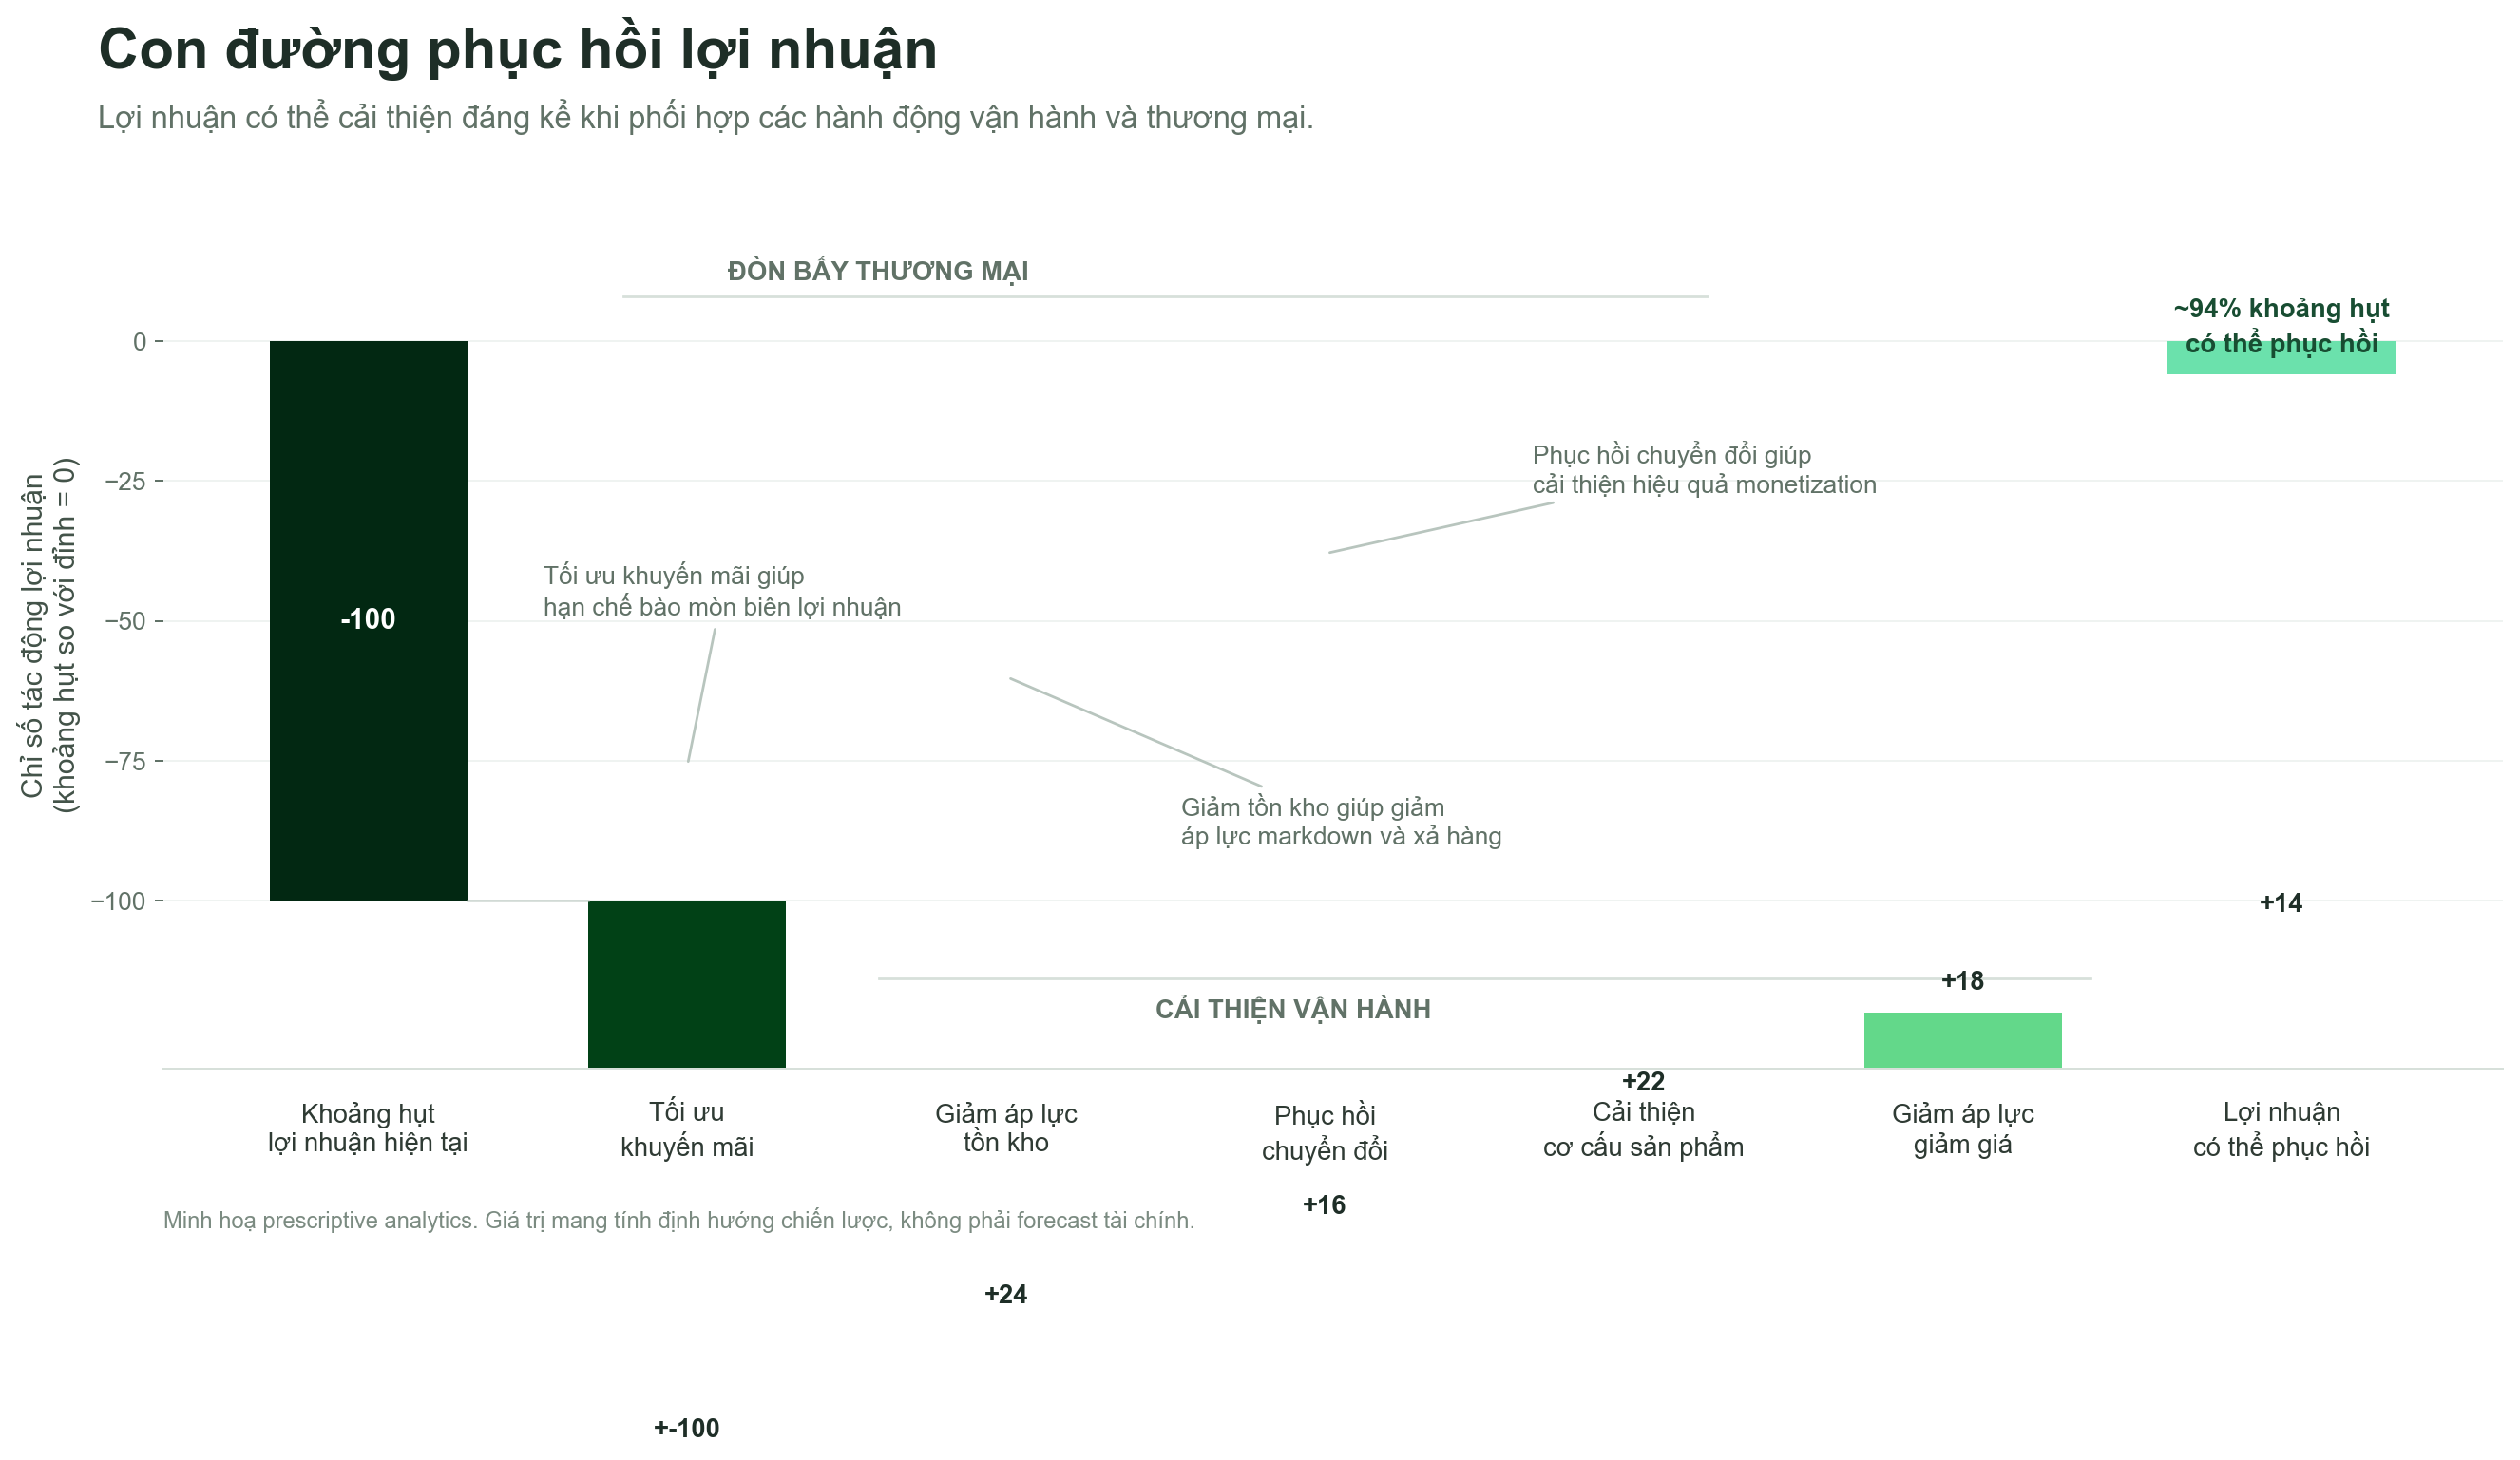

In [21]:
fig, ax = create_profit_recovery_waterfall(labels, values, contributions, final_value, colors)

png_path = OUT_DIR / "profit_recovery_waterfall.png"
svg_path = OUT_DIR / "profit_recovery_waterfall.svg"
fig.savefig(png_path, bbox_inches="tight", facecolor="white")
fig.savefig(svg_path, bbox_inches="tight", facecolor="white")

print(png_path)
print(svg_path)
plt.show()